In [ ]:
!pip install opendatasets --quiet

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/iamsouravbanerjee/indian-food-images-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ujwalnaik11
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/indian-food-images-dataset


100%|██████████| 355M/355M [00:05<00:00, 66.9MB/s]


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

SOURCE = "/content/indian-food-images-dataset/Indian Food Images/Indian Food Images"
DEST = "/content/dataset"

for split in ["train", "val", "test"]:
    os.makedirs(f"{DEST}/{split}", exist_ok=True)

for class_name in os.listdir(SOURCE):
    class_path = os.path.join(SOURCE, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    # 70% train, 30% temp
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)

    # split temp → val + test (15% each)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for split, split_imgs in zip(["train", "val", "test"],
                                [train_imgs, val_imgs, test_imgs]):

        os.makedirs(f"{DEST}/{split}/{class_name}", exist_ok=True)

        for img in split_imgs:
            shutil.copy(
                os.path.join(class_path, img),
                os.path.join(DEST, split, class_name, img)
            )

In [ ]:
import torch
BATCH_SIZE = 32
IMG_SIZE = 300
NUM_CLASSES = 80
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import timm
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"


from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(300),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

from torchvision import datasets

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


In [ ]:


targets = np.array(train_dataset.targets)

In [ ]:

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(targets),
                                     y=targets)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# ===== Model =====
NUM_CLASSES = 80


model = models.mobilenet_v2(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last blocks
for param in model.features[10:].parameters():
    param.requires_grad = True

# Replace classifier
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)

model = model.to(DEVICE)

# ===== Loss (with class weights if you used before) =====
criterion = nn.CrossEntropyLoss(weight=class_weights).to(DEVICE)

# ===== Optimizer (different LR for head vs backbone) =====
optimizer = optim.AdamW([
    {"params": model.classifier.parameters(), "lr": 1e-3},   # head
    {"params": model.features[10:].parameters(), "lr": 1e-4} # backbone
])

# ===== Scheduler (cosine + warmup style) =====
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ===== Early stopping =====
patience = 7
best_val_loss = float('inf')
epochs_no_improve = 0

EPOCHS = 20

for epoch in range(EPOCHS):
    # ===== TRAIN =====
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step()

    # ===== Save best =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "mobilenet_v2_80class.pth")
        print("✅ Saved best MobileNet model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ===== Early stopping =====
    if epochs_no_improve >= patience:
        print("🔥 Early stopping triggered")
        break

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 319.0162 | Val Loss: 42.4249 | Val Acc: 0.3643
✅ Saved best MobileNet model
Epoch 2 | Train Loss: 189.0719 | Val Loss: 31.1959 | Val Acc: 0.5179
✅ Saved best MobileNet model
Epoch 3 | Train Loss: 153.2216 | Val Loss: 28.8668 | Val Acc: 0.5429
✅ Saved best MobileNet model
Epoch 4 | Train Loss: 125.4472 | Val Loss: 26.6028 | Val Acc: 0.5589
✅ Saved best MobileNet model
Epoch 5 | Train Loss: 110.5612 | Val Loss: 25.1569 | Val Acc: 0.5946
✅ Saved best MobileNet model
Epoch 6 | Train Loss: 97.4633 | Val Loss: 24.6081 | Val Acc: 0.6214
✅ Saved best MobileNet model
Epoch 7 | Train Loss: 92.6851 | Val Loss: 23.8485 | Val Acc: 0.6321
✅ Saved best MobileNet model
Epoch 8 | Train Loss: 84.1555 | Val Loss: 23.5445 | Val Acc: 0.6375
✅ Saved best MobileNet model
Epoch 9 | Train Loss: 79.6611 | Val Loss: 23.0015 | Val Acc: 0.6339
✅ Saved best MobileNet model
Epoch 10 | Train Loss: 78.6656 | Val Loss: 22.9067 | Val Acc: 0.6357
✅ Saved best MobileNet model
Epoch 11 | Train Loss: 7

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# ===== LOAD BEST MODEL =====
model = models.mobilenet_v2(pretrained=False)

num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)

model.load_state_dict(torch.load("mobilenet_v2_80class.pth"))
model = model.to(DEVICE)

print("✅ Loaded previous best model")

# ---

# STEP 1: Unfreeze MORE layers

# Previously you used features[10:]
# Now go deeper (more layers)

for param in model.parameters():
    param.requires_grad = False

for param in model.features[7:].parameters():  # more layers
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

print("🔥 Unfroze deeper layers (features[7:])")

# ---

# ⚙️ STEP 2: VERY LOW LEARNING RATE

optimizer = optim.AdamW([
    {"params": model.classifier.parameters(), "lr": 5e-5},
    {"params": model.features[7:].parameters(), "lr": 1e-5}
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ---

#STEP 3: CONTINUE TRAINING (short + careful)

EPOCHS_EXTRA = 8
patience = 4

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS_EXTRA):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"[Refine] Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step()

    # ===== SAVE ONLY IF IMPROVED =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "mobilenet_v2_refined.pth")
        print("✅ Improved → Saved refined model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ===== EARLY STOP =====
    if epochs_no_improve >= patience:
        print("⛔ Early stopping refinement")
        break

✅ Loaded previous best model
🔥 Unfroze deeper layers (features[7:])
[Refine] Epoch 1 | Val Loss: 22.7529 | Val Acc: 0.6339
✅ Improved → Saved refined model
[Refine] Epoch 2 | Val Loss: 22.5670 | Val Acc: 0.6589
✅ Improved → Saved refined model
[Refine] Epoch 3 | Val Loss: 22.7422 | Val Acc: 0.6500
[Refine] Epoch 4 | Val Loss: 22.5350 | Val Acc: 0.6464
✅ Improved → Saved refined model
[Refine] Epoch 5 | Val Loss: 22.4411 | Val Acc: 0.6518
✅ Improved → Saved refined model
[Refine] Epoch 6 | Val Loss: 22.5168 | Val Acc: 0.6464
[Refine] Epoch 7 | Val Loss: 22.4847 | Val Acc: 0.6518
[Refine] Epoch 8 | Val Loss: 22.4585 | Val Acc: 0.6536


**Resnet**

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

NUM_CLASSES = 80

model = models.resnet50(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last layers (layer4 = highest-level features)
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW([
    {"params": model.fc.parameters(), "lr": 1e-3},      # classifier
    {"params": model.layer4.parameters(), "lr": 1e-4}   # backbone
], weight_decay=1e-4)

In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

EPOCHS = 20
patience = 7
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step()

    # ===== SAVE BEST =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "resnet50_best.pth")
        print("✅ Saved best ResNet model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ===== EARLY STOP =====
    if epochs_no_improve >= patience:
        print("⛔ Early stopping")
        break

Epoch 1 | Val Loss: 40.7721 | Val Acc: 0.3857
✅ Saved best ResNet model
Epoch 2 | Val Loss: 32.2473 | Val Acc: 0.4964
✅ Saved best ResNet model
Epoch 3 | Val Loss: 29.4791 | Val Acc: 0.5446
✅ Saved best ResNet model
Epoch 4 | Val Loss: 26.5992 | Val Acc: 0.5857
✅ Saved best ResNet model
Epoch 5 | Val Loss: 27.7077 | Val Acc: 0.5893
Epoch 6 | Val Loss: 27.6888 | Val Acc: 0.5982
Epoch 7 | Val Loss: 25.2955 | Val Acc: 0.6339
✅ Saved best ResNet model
Epoch 8 | Val Loss: 23.2096 | Val Acc: 0.6607
✅ Saved best ResNet model
Epoch 9 | Val Loss: 23.2873 | Val Acc: 0.6643
Epoch 10 | Val Loss: 22.5266 | Val Acc: 0.6821
✅ Saved best ResNet model
Epoch 11 | Val Loss: 22.2399 | Val Acc: 0.6679
✅ Saved best ResNet model
Epoch 12 | Val Loss: 22.2427 | Val Acc: 0.6732
Epoch 13 | Val Loss: 22.0416 | Val Acc: 0.6821
✅ Saved best ResNet model
Epoch 14 | Val Loss: 21.6198 | Val Acc: 0.6929
✅ Saved best ResNet model
Epoch 15 | Val Loss: 21.7806 | Val Acc: 0.6911
Epoch 16 | Val Loss: 21.7296 | Val Acc: 0.69

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

# ===== LOAD BEST MODEL =====
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model.load_state_dict(torch.load("resnet50_best.pth"))
model = model.to(DEVICE)

print("✅ Loaded previous best ResNet")

# ===== FREEZE ALL =====
for param in model.parameters():
    param.requires_grad = False

# ===== UNFREEZE layer4 + layer3 =====
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.layer3.parameters():
    param.requires_grad = True

# Always train classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("🔥 Unfroze layer3 + layer4")

# ===== OPTIMIZER (DIFFERENT LR) =====
optimizer = optim.AdamW([
    {"params": model.fc.parameters(), "lr": 1e-4},
    {"params": model.layer4.parameters(), "lr": 5e-5},
    {"params": model.layer3.parameters(), "lr": 1e-5}
], weight_decay=1e-4)

# ===== SCHEDULER =====
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8)

# ===== LOSS =====
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ===== TRAIN SETTINGS =====
EPOCHS = 8
patience = 3

best_val_loss = float("inf")
epochs_no_improve = 0

# ===== TRAIN LOOP =====
for epoch in range(EPOCHS):

    # ----- TRAIN -----
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"[Refine] Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step()

    # ===== SAVE ONLY IF IMPROVED =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "resnet50_refined.pth")
        print("✅ Improved → Saved refined model")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ===== EARLY STOP =====
    if epochs_no_improve >= patience:
        print("⛔ Early stopping refinement")
        break

✅ Loaded previous best ResNet
🔥 Unfroze layer3 + layer4
[Refine] Epoch 1 | Val Loss: 23.0385 | Val Acc: 0.6679
✅ Improved → Saved refined model
[Refine] Epoch 2 | Val Loss: 22.4367 | Val Acc: 0.6679
✅ Improved → Saved refined model
[Refine] Epoch 3 | Val Loss: 22.1982 | Val Acc: 0.6786
✅ Improved → Saved refined model
[Refine] Epoch 4 | Val Loss: 21.9927 | Val Acc: 0.6982
✅ Improved → Saved refined model
[Refine] Epoch 5 | Val Loss: 22.4664 | Val Acc: 0.6786
[Refine] Epoch 6 | Val Loss: 21.7589 | Val Acc: 0.6857
✅ Improved → Saved refined model
[Refine] Epoch 7 | Val Loss: 21.1805 | Val Acc: 0.6946
✅ Improved → Saved refined model
[Refine] Epoch 8 | Val Loss: 21.3384 | Val Acc: 0.6982


In [ ]:
import torch
import torch.nn as nn
import timm
import torchvision.models as tv_models # Changed alias to tv_models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 80

def load_all_models():
    models_list = []

    # ===== MobileNet =====
    mobilenet = tv_models.mobilenet_v2(pretrained=False) # Using tv_models
    mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, NUM_CLASSES)
    mobilenet.load_state_dict(torch.load("mobilenet_v2_refined.pth"))
    mobilenet = mobilenet.to(DEVICE)
    mobilenet.eval()
    models_list.append(mobilenet)

    # ===== ResNet =====
    resnet = tv_models.resnet50(pretrained=False) # Using tv_models
    resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
    resnet.load_state_dict(torch.load("resnet50_best.pth"))  # your saved file
    resnet = resnet.to(DEVICE)
    resnet.eval()
    models_list.append(resnet)

    print(f"✅ Loaded {len(models_list)} models for ensemble")

    return models_list

In [ ]:
def tta_ensemble_predict(models, image):
    image = image.to(DEVICE)

    # TTA transforms
    images = [
        image,
        torch.flip(image, dims=[3]),  # horizontal flip
    ]

    preds = []

    with torch.no_grad():
        for model in models:
            model_preds = []

            for img in images:
                out = model(img)
                model_preds.append(torch.softmax(out, dim=1))

            # average TTA predictions
            model_pred = torch.mean(torch.stack(model_preds), dim=0)
            preds.append(model_pred)

    # FINAL ENSEMBLE
    final_pred = torch.mean(torch.stack(preds), dim=0)

    return final_pred

In [ ]:
def weighted_ensemble_predict(models, image):
    image = image.to(DEVICE)

    weights = []

    # Example weights (tune later)
    for model in models:
        if "efficientnet" in str(type(model)).lower():
            weights.append(0.4)
        elif "resnet" in str(type(model)).lower():
            weights.append(0.35)
        else:
            weights.append(0.25)

    images = [image, torch.flip(image, dims=[3])]

    final_pred = 0

    with torch.no_grad():
        for model, w in zip(models, weights):
            model_preds = []

            for img in images:
                out = model(img)
                model_preds.append(torch.softmax(out, dim=1))

            model_pred = torch.mean(torch.stack(model_preds), dim=0)
            final_pred += w * model_pred

    return final_pred

In [ ]:
def predict(models, image, use_weighted=True):
    if use_weighted:
        pred = weighted_ensemble_predict(models, image)
    else:
        pred = tta_ensemble_predict(models, image)

    return torch.argmax(pred, dim=1).item()

In [ ]:
from PIL import Image
import os

models = load_all_models()

test_dir = "/content/dataset/test"

# Get class names from the dataset
class_names = [None] * NUM_CLASSES
for class_name, idx in train_dataset.class_to_idx.items():
    class_names[idx] = class_name

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img = Image.open(img_path).convert("RGB")
        img_tensor = val_transform(img).unsqueeze(0) # Use val_transform instead of undefined 'transform'

        pred = predict(models, img_tensor)
        pred_class = class_names[pred]

        print(f"True: {class_folder} | Pred: {pred_class}")

✅ Loaded 2 models for ensemble
True: cham_cham | Pred: cham_cham
True: cham_cham | Pred: modak
True: cham_cham | Pred: cham_cham
True: cham_cham | Pred: shrikhand
True: cham_cham | Pred: kalakand
True: cham_cham | Pred: cham_cham
True: cham_cham | Pred: cham_cham
True: cham_cham | Pred: sandesh
True: dal_tadka | Pred: dal_tadka
True: dal_tadka | Pred: daal_baati_churma
True: dal_tadka | Pred: litti_chokha
True: dal_tadka | Pred: dal_tadka
True: dal_tadka | Pred: dal_tadka
True: dal_tadka | Pred: dal_tadka
True: dal_tadka | Pred: dal_tadka
True: dal_tadka | Pred: dal_tadka
True: kofta | Pred: kofta
True: kofta | Pred: dum_aloo
True: kofta | Pred: kofta
True: kofta | Pred: kofta
True: kofta | Pred: kofta
True: kofta | Pred: kofta
True: kofta | Pred: palak_paneer
True: kofta | Pred: dum_aloo
True: rasgulla | Pred: rasgulla
True: rasgulla | Pred: rasgulla
True: rasgulla | Pred: rasgulla
True: rasgulla | Pred: rasgulla
True: rasgulla | Pred: cham_cham
True: rasgulla | Pred: rasgulla
True: r

In [ ]:
from collections import defaultdict

class_correct = defaultdict(int)
class_total = defaultdict(int)

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path).convert("RGB")
        img_tensor = val_transform(img).unsqueeze(0)

        pred = predict(models, img_tensor)
        pred_class = class_names[pred]

        if pred_class == class_folder:
            class_correct[class_folder] += 1

        class_total[class_folder] += 1

# Print per-class accuracy
for cls in class_total:
    acc = class_correct[cls] / class_total[cls]
    print(f"{cls}: {acc:.2f}")

cham_cham: 0.50
dal_tadka: 0.75
kofta: 0.62
rasgulla: 0.88
poha: 1.00
gajar_ka_halwa: 0.75
lyangcha: 0.62
chak_hao_kheer: 0.88
butter_chicken: 0.62
dum_aloo: 0.62
anarsa: 0.62
doodhpak: 0.38
ras_malai: 0.88
aloo_shimla_mirch: 0.62
chapati: 0.75
dharwad_pedha: 0.88
gulab_jamun: 0.75
kadhi_pakoda: 0.62
sheer_korma: 0.88
imarti: 0.88
chicken_razala: 0.88
boondi: 0.88
karela_bharta: 0.50
ariselu: 1.00
basundi: 0.50
palak_paneer: 1.00
poornalu: 0.75
kadai_paneer: 0.88
modak: 0.75
ledikeni: 0.38
misti_doi: 0.88
naan: 1.00
gavvalu: 0.88
aloo_matar: 0.50
mysore_pak: 0.88
aloo_methi: 0.88
biryani: 0.75
pithe: 0.38
misi_roti: 0.88
chicken_tikka_masala: 0.38
navrattan_korma: 0.75
aloo_tikki: 0.75
litti_chokha: 1.00
kachori: 0.62
chhena_kheeri: 0.00
kalakand: 0.88
paneer_butter_masala: 0.50
sandesh: 0.12
pootharekulu: 1.00
sohan_papdi: 0.88
aloo_gobi: 0.75
daal_puri: 0.62
double_ka_meetha: 0.50
jalebi: 1.00
sheera: 0.75
maach_jhol: 0.88
shankarpali: 1.00
makki_di_roti_sarson_da_saag: 1.00
ghevar: 

In [ ]:
import os
from PIL import Image
import torch

models = load_all_models()  #MobileNet + ResNet

test_dir = "/content/dataset/test"

correct = 0
total = 0

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = os.path.join(class_path, img_name)

        # Load image
        img = Image.open(img_path).convert("RGB")
        img_tensor = val_transform(img).unsqueeze(0)

        # Predict
        pred = predict(models, img_tensor)   # your ensemble predict
        pred_class = class_names[pred]

        # Compare with true label
        if pred_class == class_folder:
            correct += 1

        total += 1

# ===== FINAL ACCURACY =====
accuracy = correct / total

print("\n🔥 FINAL TEST ACCURACY:", accuracy)

✅ Loaded 2 models for ensemble

🔥 FINAL TEST ACCURACY: 0.7515625


In [ ]:
import os
from PIL import Image

y_true = []
y_pred = []

models = load_all_models()

test_dir = "/content/dataset/test"

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        img_path = os.path.join(class_path, img_name)

        # Load image
        img = Image.open(img_path).convert("RGB")
        img_tensor = val_transform(img).unsqueeze(0)

        # Predict
        pred = predict(models, img_tensor)

        # Store results
        y_pred.append(pred)
        y_true.append(class_names.index(class_folder))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Loaded 2 models for ensemble


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=class_names))


                              precision    recall  f1-score   support

                   adhirasam       1.00      0.88      0.93         8
                   aloo_gobi       0.86      0.75      0.80         8
                  aloo_matar       1.00      0.50      0.67         8
                  aloo_methi       0.88      0.88      0.88         8
           aloo_shimla_mirch       1.00      0.62      0.77         8
                  aloo_tikki       0.86      0.75      0.80         8
                      anarsa       0.71      0.62      0.67         8
                     ariselu       0.73      1.00      0.84         8
                bandar_laddu       0.67      0.75      0.71         8
                     basundi       0.50      0.50      0.50         8
                     bhatura       0.75      0.75      0.75         8
               bhindi_masala       0.78      0.88      0.82         8
                     biryani       0.75      0.75      0.75         8
                   

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Loaded 2 models for ensemble


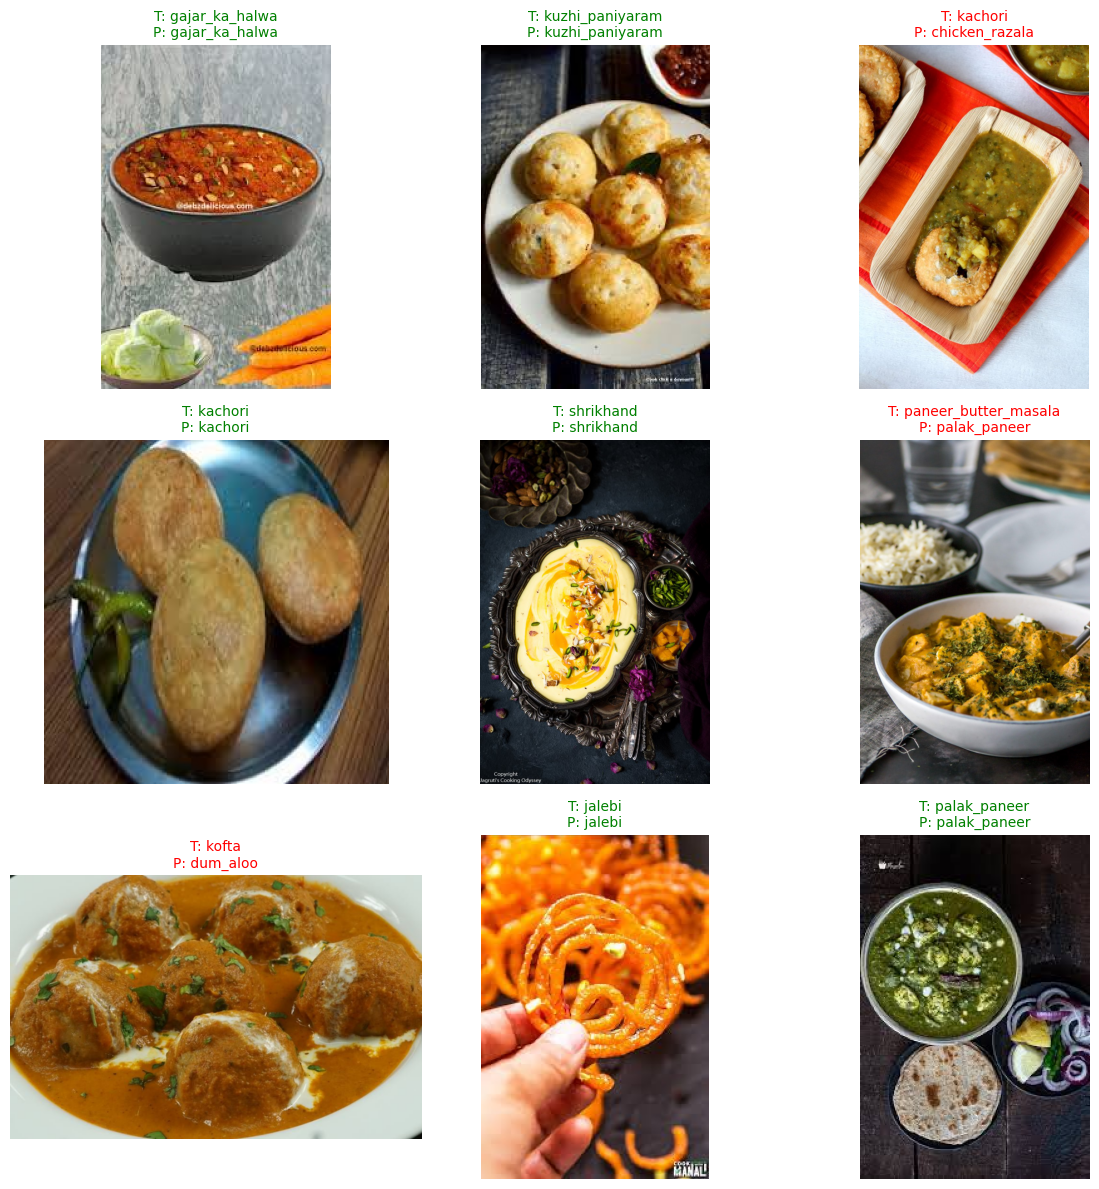

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

models = load_all_models()

test_dir = "/content/dataset/test"

# ===== Collect all image paths =====
image_paths = []

for class_folder in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_folder)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append((os.path.join(class_path, img_name), class_folder))

# ===== Pick random samples =====
num_samples = 9
samples = random.sample(image_paths, num_samples)

# ===== Plot =====
plt.figure(figsize=(12, 12))

for i, (img_path, true_label) in enumerate(samples):

    # Load image
    img = Image.open(img_path).convert("RGB")
    img_tensor = val_transform(img).unsqueeze(0)

    # Predict
    pred = predict(models, img_tensor)
    pred_label = class_names[pred]

    # Plot
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis("off")

    # Color code (green = correct, red = wrong)
    color = "green" if pred_label == true_label else "red"

    plt.title(f"T: {true_label}\nP: {pred_label}", color=color, fontsize=10)

plt.tight_layout()
plt.show()

https://www.kaggle.com/code/dima806/indian-food-image-detection-vit